# ResNet101 — Lentil Disease Classification (Phase 1: Teacher Selection)

**Objective:** Evaluate ResNet101 as a candidate teacher model for cross-crop knowledge distillation.

**Dataset:** Lentil Augmented Dataset (4 classes: Ascochyta Blight, Lentil Rust, Normal, Powdery Mildew)
- Training: 4,540 images | Validation: 456 images | Test: 457 images

**Approach:** Transfer learning with ImageNet-pretrained ResNet101. Two experiments are conducted:
1. **Experiment 1 (Functional API):** Frozen base + custom head (GAP → Dense 1024 → Softmax)
2. **Experiment 2 (Sequential API):** All layers trainable, Dense 4096, Dropout 0.2

**Context:** This is part of Phase 1 of the project. **ResNet101 was selected as the best teacher model** based on its performance in these experiments.

## Imports and Setup

Importing required libraries and dependencies.

In [2]:
import tensorflow as tf
from tensorflow.keras.applications import ResNet101
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
import os
from tensorflow.keras.layers import Flatten, Dense

## Data Loading and Preprocessing

Loading the dataset and applying preprocessing (normalization, augmentation, etc.).

In [4]:
train_dir = r'C:\Users\k nithin\OneDrive\Desktop\M.Tech Project\Lentil Augmented Dataset\Train'
val_dir = r'C:\Users\k nithin\OneDrive\Desktop\M.Tech Project\Lentil Augmented Dataset\Validation'
img_size = 224
batch_size = 32
seed = 123

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    seed=seed,
    image_size=(img_size,img_size),
    batch_size=batch_size,
    shuffle=True
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    val_dir,
    seed=seed,
    image_size=(img_size,img_size),
    batch_size=batch_size,
    shuffle=True
)


AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)

Found 4540 files belonging to 4 classes.
Found 456 files belonging to 4 classes.


## Model Architecture

Building the ResNet101 model with transfer learning. Using ImageNet pre-trained weights with custom classification head for the disease classes.

In [6]:
base_model = ResNet101(weights='imagenet', include_top=False, input_shape=(img_size, img_size, 3))

for layer in base_model.layers:
    layer.trainable = False 

x = GlobalAveragePooling2D()(base_model.output)
x = Dense(1024, activation='relu')(x)
output = Dense(4, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

171446536/171446536 ━━━━━━━━━━━━━━━━━━━━ 17s 0us/step


## Model Architecture

Loading ResNet101 pre-trained on ImageNet with the top classification layer removed. All base layers are frozen (non-trainable) and a custom classification head is added for 4-class lentil disease classification.

In [7]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)      │ (None, 224, 224, 3)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1_pad (ZeroPadding2D)     │ (None, 230, 230, 3)       │               0 │ input_layer[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1_conv (Conv2D)           │ (None, 112, 112, 64)      │           9,472 │ conv1_pad[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1_bn (BatchNormalization) │ (None, 112, 112, 64)      │             256 │ conv1_conv[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1_relu (Activation)       │ (None, 112, 112, 64)      │               0 │ conv1_bn[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ pool1_pad (ZeroPadding2D)     │ (None, 114, 114, 64)      │               0 │ conv1_relu[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ pool1_pool (MaxPooling2D)     │ (None, 56, 56, 64)        │               0 │ pool1_pad[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_1_conv (Conv2D)  │ (None, 56, 56, 64)        │           4,160 │ pool1_pool[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_1_bn             │ (None, 56, 56, 64)        │             256 │ conv2_block1_1_conv[0][0]  │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_1_relu           │ (None, 56, 56, 64)        │               0 │ conv2_block1_1_bn[0][0]    │
│ (Activation)                  │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_2_conv (Conv2D)  │ (None, 56, 56, 64)        │          36,928 │ conv2_block1_1_relu[0][0]  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_2_bn             │ (None, 56, 56, 64)        │             256 │ conv2_block1_2_conv[0][0]  │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_2_relu           │ (None, 56, 56, 64)        │               0 │ conv2_block1_2_bn[0][0]    │
│ (Activation)                  │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_0_conv (Conv2D)  │ (None, 56, 56, 256)       │          16,640 │ pool1_pool[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_3_conv (Conv2D)  │ (None, 56, 56, 256)       │          16,640 │ conv2_block1_2_relu[0][0]  │
├───────────────────────────────┼───────────────────────────┼───────────────

 Total params: 44,760,452 (170.75 MB)

 Trainable params: 2,102,276 (8.02 MB)

 Non-trainable params: 42,658,176 (162.73 MB)

## Imports and Setup

Importing required libraries and dependencies.

In [10]:
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.losses import SparseCategoricalCrossentropy
from tensorflow.keras.callbacks import ModelCheckpoint

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)
checkpoint = ModelCheckpoint(
    'best_model.keras',
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

## Training Configuration

- **Loss:** SparseCategoricalCrossentropy
- **Optimizer:** Adam (default learning rate)
- **Callbacks:** EarlyStopping (patience=5, restore best weights) and ModelCheckpoint (monitor val_accuracy)
- **Epochs:** 20 (with early stopping)

In [12]:
model.compile(
    optimizer='adam',
    loss=SparseCategoricalCrossentropy(from_logits=False), 
    metrics=['accuracy']
)
history = model.fit(
    train_ds,
    epochs=20,
    validation_data=val_ds,
    callbacks=[checkpoint, early_stopping],
    shuffle = False
)

Epoch 1/20
142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5258 - loss: 1.9059
Epoch 1: val_accuracy improved from -inf to 0.77412, saving model to best_model.keras
142/142 ━━━━━━━━━━━━━━━━━━━━ 272s 2s/step - accuracy: 0.5266 - loss: 1.9004 - val_accuracy: 0.7741 - val_loss: 0.6726
Epoch 2/20
142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7585 - loss: 0.6427
Epoch 2: val_accuracy did not improve from 0.77412
142/142 ━━━━━━━━━━━━━━━━━━━━ 258s 2s/step - accuracy: 0.7586 - loss: 0.6424 - val_accuracy: 0.7237 - val_loss: 0.7077
Epoch 3/20
142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7841 - loss: 0.5517
Epoch 3: val_accuracy did not improve from 0.77412
142/142 ━━━━━━━━━━━━━━━━━━━━ 262s 2s/step - accuracy: 0.7842 - loss: 0.5514 - val_accuracy: 0.7281 - val_loss: 0.7450
Epoch 4/20
142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8284 - loss: 0.4675
Epoch 4: val_accuracy did not improve from 0.77412
142/142 ━━━━━━━━━━━━━━━━━━━━ 262s 2s/step - accuracy: 0.8284 - loss

## Performance Metrics

Visualizing training curves and computing detailed metrics (confusion matrix, precision, recall, F1-score).

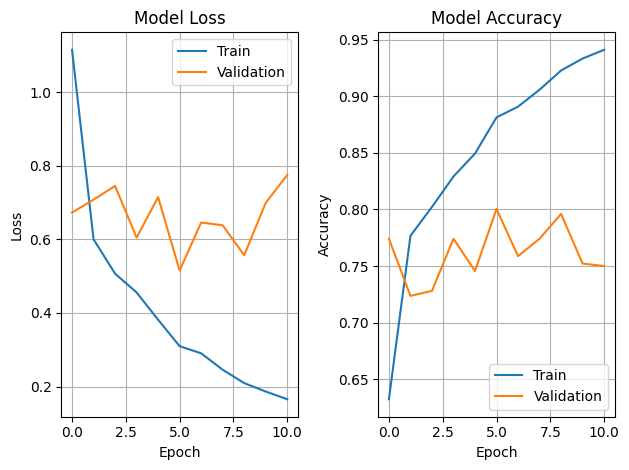

In [14]:
import os
import cv2
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
import random
from PIL import Image
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper right')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'])  
plt.plot(history.history['val_accuracy']) 
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='lower right')
plt.grid(True)

plt.tight_layout()
save_path = r"C:\Users\k nithin\OneDrive\Desktop\M.Tech Project\loss_accuracy_curve.png"
plt.savefig(save_path, dpi=300, bbox_inches='tight') 
plt.show()

## Training Results — Experiment 1

Visualizing the training and validation loss/accuracy curves to assess model convergence and potential overfitting.

In [16]:
test_ds = tf.keras.utils.image_dataset_from_directory(
    r"C:\Users\k nithin\OneDrive\Desktop\M.Tech Project\Lentil Augmented Dataset\Test",
    seed= 123,
    image_size=img_size,
    batch_size=batch_size,
    shuffle = False
)

Found 457 files belonging to 4 classes.


## Model Evaluation

Evaluating the model performance on train, validation, and test datasets.

In [18]:
model.evaluate(test_ds)

15/15 ━━━━━━━━━━━━━━━━━━━━ 22s 1s/step - accuracy: 0.8236 - loss: 0.5001


[0.5208621621131897, 0.8161925673484802]

In [19]:
ts_length = len(test_ds)
test_batch_size = test_batch_size = max(sorted([ts_length // n for n in range(1, ts_length + 1) if ts_length%n == 0 and ts_length/n <= 80]))
test_steps = ts_length // test_batch_size

train_score = model.evaluate(train_ds, steps= test_steps, verbose= 1)
valid_score = model.evaluate(val_ds, steps= test_steps, verbose= 1)
test_score = model.evaluate(test_ds)

print("Train Loss: ", train_score[0])
print("Train Accuracy: ", train_score[1])
print('-' * 20)
print("Validation Loss: ", valid_score[0])
print("Validation Accuracy: ", valid_score[1])
print('-' * 20)
print("Test Loss: ", test_score[0])
print("Test Accuracy: ", test_score[1])

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.8438 - loss: 0.3837
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.8438 - loss: 0.5326
15/15 ━━━━━━━━━━━━━━━━━━━━ 23s 2s/step - accuracy: 0.8236 - loss: 0.5001
Train Loss:  0.3836524188518524
Train Accuracy:  0.84375
--------------------
Validation Loss:  0.532616138458252
Validation Accuracy:  0.84375
--------------------
Test Loss:  0.5208621621131897
Test Accuracy:  0.8161925673484802


## Performance Metrics

Visualizing training curves and computing detailed metrics (confusion matrix, precision, recall, F1-score).

In [21]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

def evaluate_model(y_true, y_pred, class_names):
    """
    Plots the confusion matrix and prints the classification report.

    Args:
        y_true (array-like): True labels.
        y_pred (array-like): Predicted labels.
        class_names (list): List of class names.
    """
    cm = confusion_matrix(y_true, y_pred)

    print("\nClassification Report:\n")
    print(classification_report(y_true, y_pred, target_names=class_names))


    cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm_percent, annot=True, fmt=".2f", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
    plt.title("Confusion Matrix (in %)")
    plt.xlabel("Predicted Labels")
    plt.ylabel("True Labels")
    save_path = r"C:\Users\k nithin\OneDrive\Desktop\M.Tech Project\Confusion Matrix.png"
    plt.savefig(save_path, dpi=300, bbox_inches='tight') 
    plt.show()

## Evaluation Metrics — Experiment 1

Computing the confusion matrix (percentage-based) and classification report (precision, recall, F1-score) on the test set.

15/15 ━━━━━━━━━━━━━━━━━━━━ 29s 2s/step

Classification Report:

                  precision    recall  f1-score   support

Ascochyta blight       0.80      0.84      0.82       111
     Lentil Rust       0.86      0.94      0.90        95
          Normal       0.84      0.62      0.71       143
  Powdery Mildew       0.77      0.95      0.85       108

        accuracy                           0.82       457
       macro avg       0.82      0.84      0.82       457
    weighted avg       0.82      0.82      0.81       457



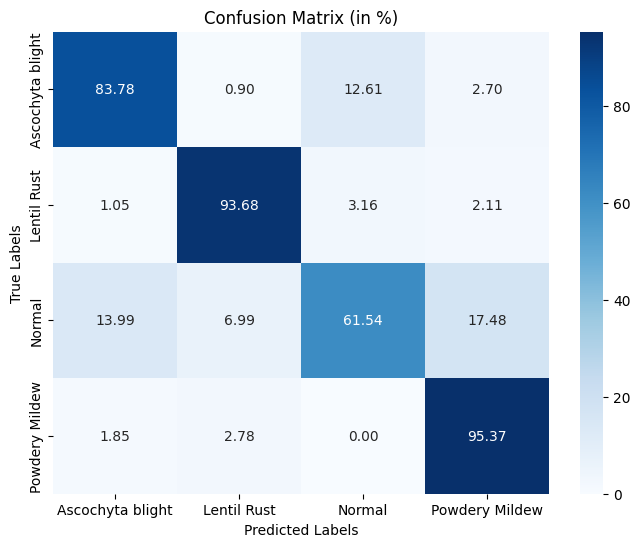

In [22]:
y_pred_probs = model.predict(test_ds)
y_pred = np.argmax(y_pred_probs, axis=1)

y_true = np.concatenate([y.numpy() for x, y in test_ds], axis=0)

class_names =  ['Ascochyta blight', 'Lentil Rust', 'Normal', 'Powdery Mildew']

evaluate_model(y_true, y_pred, class_names)

## Performance Metrics

Visualizing training curves and computing detailed metrics (confusion matrix, precision, recall, F1-score).

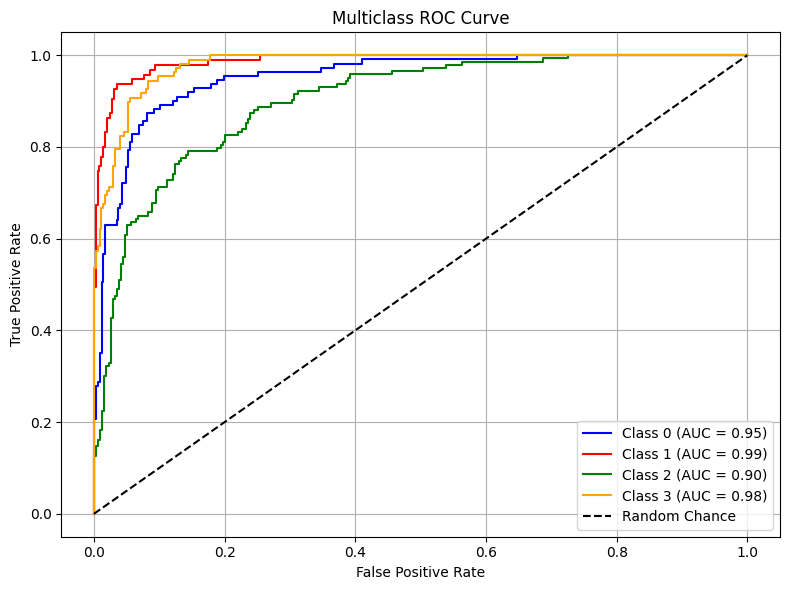

In [23]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np

n_classes = y_pred_probs.shape[1]

y_true_bin = label_binarize(y_true, classes=list(range(n_classes)))

fpr = {}
tpr = {}
roc_auc = {}

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_pred_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(8, 6))
colors = ['blue', 'red', 'green', 'orange', 'purple', 'cyan']

for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], color=colors[i % len(colors)],
             label=f'Class {i} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Chance')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multiclass ROC Curve')
plt.legend(loc='lower right')
plt.grid(True)
save_path = r"C:\Users\k nithin\OneDrive\Desktop\M.Tech Project\ROC_Curve.png"
plt.savefig(save_path, dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()

## ROC Curves — Experiment 1

Plotting per-class ROC curves with AUC scores to evaluate the model's discriminative ability across all disease classes.

In [30]:
import tensorflow as tf
from tensorflow.keras.applications import ResNet101
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
import os
from tensorflow.keras.layers import Flatten, Dense
from tensorflow.keras import layers, models, applications, optimizers

---
## Experiment 2: Full Fine-Tuning with Sequential API

In this experiment, all layers of ResNet101 are made trainable (unfrozen). The model uses a Sequential architecture with a larger Dense layer (4096 units), Dropout (0.2), and categorical cross-entropy loss. This tests whether end-to-end fine-tuning improves upon the frozen-base approach.

In [32]:
train_dir = r'C:\Users\k nithin\OneDrive\Desktop\M.Tech Project\Lentil Augmented Dataset\Train'
val_dir = r'C:\Users\k nithin\OneDrive\Desktop\M.Tech Project\Lentil Augmented Dataset\Validation'
img_size = 224
batch_size = 32
seed = 123
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    seed=seed,
    image_size=(img_size,img_size),
    batch_size=batch_size,
    shuffle=True,
    label_mode='categorical' 
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    val_dir,
    seed=seed,
    image_size=(img_size,img_size),
    batch_size=batch_size,
    shuffle=True,
    label_mode='categorical'
)


AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)

Found 4540 files belonging to 4 classes.
Found 456 files belonging to 4 classes.


## Imports and Setup

Importing required libraries and dependencies.

In [34]:
from keras import backend as K
from keras.preprocessing import image
from keras.models import Model, Sequential
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.layers import Activation, Dropout, Flatten, Dense
from keras.layers import Conv2D, MaxPooling2D, BatchNormalization, GlobalAveragePooling2D

## Model Architecture

Building the ResNet101 model with transfer learning. Using ImageNet pre-trained weights with custom classification head for the disease classes.

In [36]:
resnet = tf.keras.applications.ResNet101(
    weights='imagenet',
    include_top=False,
    input_shape= (img_size,img_size,3))

for layer in resnet.layers:
    layer.trainable = False

resnet.trainable = True
def build_model():
    model = Sequential()
    model.add(resnet)
    model.add(GlobalAveragePooling2D())
    model.add(Dense(4096, activation='relu'))
    model.add(Dropout(0.2))
    model.add(Dense(4, activation='softmax'))
    
    model.compile(
        loss='categorical_crossentropy',
        optimizer=optimizers.Adam(1e-4),
        metrics=['accuracy'])
     
    return model

model = build_model()

## Code

In [38]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ resnet101 (Functional)               │ (None, 7, 7, 2048)          │      42,658,176 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d_1           │ (None, 2048)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 4096)                │       8,392,704 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 4096)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 4)                   │          16,388 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 51,067,268 (194.81 MB)

 Trainable params: 8,409,092 (32.08 MB)

 Non-trainable params: 42,658,176 (162.73 MB)

## Imports and Setup

Importing required libraries and dependencies.

In [40]:
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.losses import SparseCategoricalCrossentropy

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)
checkpoint = ModelCheckpoint(
    'best_model.keras',
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

## Training

Compiling and training the model with appropriate callbacks (EarlyStopping, ModelCheckpoint) to prevent overfitting and save the best model.

In [42]:
history = model.fit(
    train_ds,
    epochs=20,
    validation_data=val_ds,
    callbacks=[early_stopping,checkpoint],
    shuffle = False
)  

Epoch 1/20
142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5502 - loss: 1.0964
Epoch 1: val_accuracy improved from -inf to 0.73904, saving model to best_model.keras
142/142 ━━━━━━━━━━━━━━━━━━━━ 276s 2s/step - accuracy: 0.5508 - loss: 1.0951 - val_accuracy: 0.7390 - val_loss: 0.6846
Epoch 2/20
142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7498 - loss: 0.6609
Epoch 2: val_accuracy did not improve from 0.73904
142/142 ━━━━━━━━━━━━━━━━━━━━ 265s 2s/step - accuracy: 0.7499 - loss: 0.6607 - val_accuracy: 0.7215 - val_loss: 0.7364
Epoch 3/20
142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8013 - loss: 0.5246
Epoch 3: val_accuracy did not improve from 0.73904
142/142 ━━━━━━━━━━━━━━━━━━━━ 264s 2s/step - accuracy: 0.8014 - loss: 0.5245 - val_accuracy: 0.7281 - val_loss: 0.7193
Epoch 4/20
142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8204 - loss: 0.4735
Epoch 4: val_accuracy did not improve from 0.73904
142/142 ━━━━━━━━━━━━━━━━━━━━ 260s 2s/step - accuracy: 0.8204 - loss

## Performance Metrics

Visualizing training curves and computing detailed metrics (confusion matrix, precision, recall, F1-score).

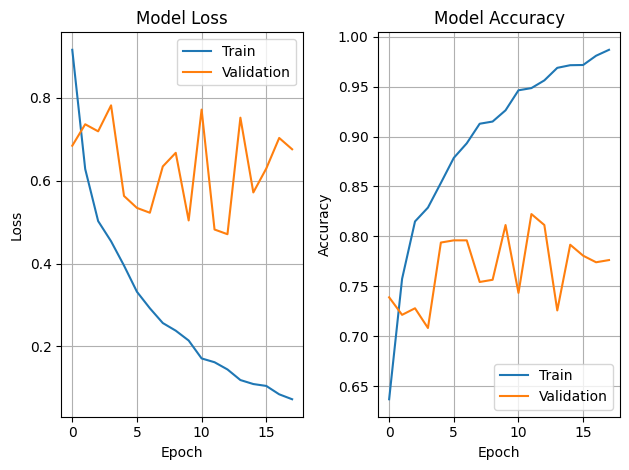

In [44]:
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper right')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'])  
plt.plot(history.history['val_accuracy']) 
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='lower right')
plt.grid(True)

plt.tight_layout()
save_path = r"C:\Users\k nithin\OneDrive\Desktop\M.Tech Project\loss_accuracy_curve_1.png"
plt.savefig(save_path, dpi=300, bbox_inches='tight') 
plt.show()

## Training Results — Experiment 2

In [46]:
test_ds = tf.keras.utils.image_dataset_from_directory(
    r"C:\Users\k nithin\OneDrive\Desktop\M.Tech Project\Lentil Augmented Dataset\Test",
    seed= 123,
    image_size=img_size,
    batch_size=batch_size,
    shuffle = False,
    label_mode='categorical'
)

Found 457 files belonging to 4 classes.


## Model Evaluation

Evaluating the model performance on train, validation, and test datasets.

In [48]:
model.evaluate(test_ds)

15/15 ━━━━━━━━━━━━━━━━━━━━ 23s 2s/step - accuracy: 0.7972 - loss: 0.5623


[0.48288407921791077, 0.8205689191818237]

In [50]:
ts_length = len(test_ds)
test_batch_size = test_batch_size = max(sorted([ts_length // n for n in range(1, ts_length + 1) if ts_length%n == 0 and ts_length/n <= 80]))
test_steps = ts_length // test_batch_size

train_score = model.evaluate(train_ds, steps= test_steps, verbose= 1)
valid_score = model.evaluate(val_ds, steps= test_steps, verbose= 1)
test_score = model.evaluate(test_ds)

print("Train Loss: ", train_score[0])
print("Train Accuracy: ", train_score[1])
print('-' * 20)
print("Validation Loss: ", valid_score[0])
print("Validation Accuracy: ", valid_score[1])
print('-' * 20)
print("Test Loss: ", test_score[0])
print("Test Accuracy: ", test_score[1])

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 1.0000 - loss: 0.1188
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.8438 - loss: 0.4555
15/15 ━━━━━━━━━━━━━━━━━━━━ 24s 2s/step - accuracy: 0.7972 - loss: 0.5623
Train Loss:  0.11875602602958679
Train Accuracy:  1.0
--------------------
Validation Loss:  0.45551377534866333
Validation Accuracy:  0.84375
--------------------
Test Loss:  0.48288407921791077
Test Accuracy:  0.8205689191818237


## Performance Metrics

Visualizing training curves and computing detailed metrics (confusion matrix, precision, recall, F1-score).

In [51]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

def evaluate_model(y_true, y_pred, class_names):
    """
    Plots the confusion matrix and prints the classification report.

    Args:
        y_true (array-like): True labels (1D array of class indices).
        y_pred (array-like): Predicted labels (1D array of class indices).
        class_names (list): List of class names.
    """
    cm = confusion_matrix(y_true, y_pred)

    print("\nClassification Report:\n")   
    print(classification_report(y_true, y_pred, target_names=class_names))

    cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm_percent, annot=True, fmt=".2f", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names)
    plt.title("Confusion Matrix (in %)")
    plt.xlabel("Predicted Labels")
    plt.ylabel("True Labels")
    save_path = r"C:\Users\k nithin\OneDrive\Desktop\M.Tech Project\Confusion Matrix_1.png"
    plt.savefig(save_path, dpi=300, bbox_inches='tight') 
    plt.show()

## Evaluation Metrics — Experiment 2

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step

Classification Report:

                  precision    recall  f1-score   support

Ascochyta blight       0.90      0.78      0.84       111
     Lentil Rust       0.84      0.91      0.87        95
          Normal       0.77      0.68      0.72       143
  Powdery Mildew       0.80      0.97      0.88       108

        accuracy                           0.82       457
       macro avg       0.83      0.83      0.83       457
    weighted avg       0.82

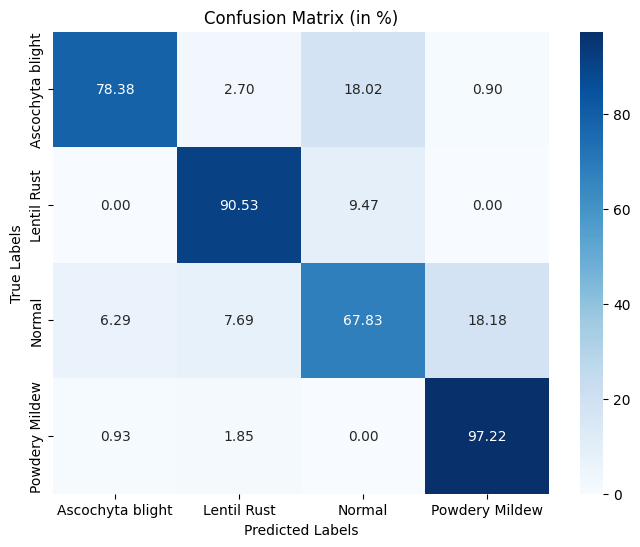

In [52]:
y_true = []
y_pred_proba = []

for images, labels in test_ds:
    y_true.append(labels.numpy())
    preds = model.predict(images)
    y_pred_proba.append(preds)

y_true = np.vstack(y_true)
y_pred_proba = np.vstack(y_pred_proba)

if y_true.shape[1] > 1:
    y_true = np.argmax(y_true, axis=1)
else:
    y_true = y_true.flatten()

y_pred = np.argmax(y_pred_proba, axis=1)

class_names = ['Ascochyta blight', 'Lentil Rust', 'Normal', 'Powdery Mildew']

evaluate_model(y_true, y_pred, class_names)

## Performance Metrics

Visualizing training curves and computing detailed metrics (confusion matrix, precision, recall, F1-score).

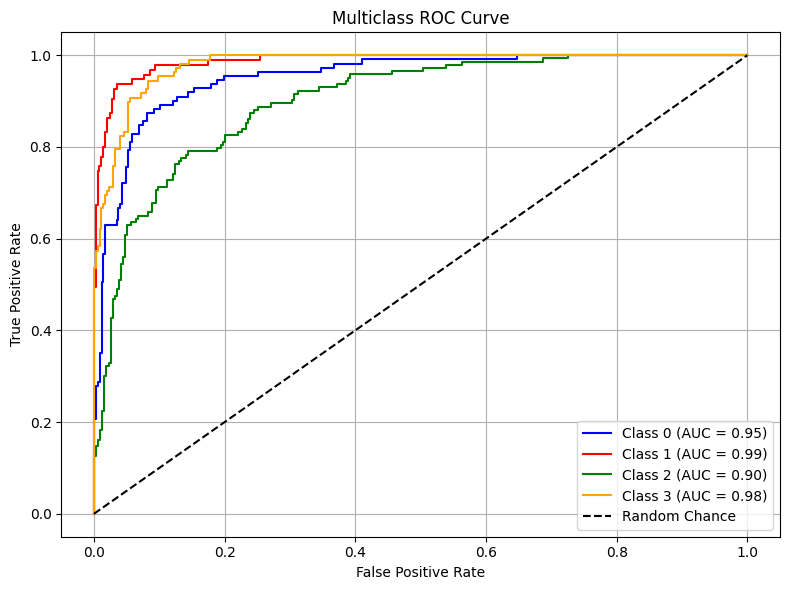

In [55]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np

n_classes = y_pred_probs.shape[1]

y_true_bin = label_binarize(y_true, classes=list(range(n_classes)))

fpr = {}
tpr = {}
roc_auc = {}

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_pred_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(8, 6))
colors = ['blue', 'red', 'green', 'orange', 'purple', 'cyan']

for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], color=colors[i % len(colors)],
             label=f'Class {i} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Chance')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multiclass ROC Curve')
plt.legend(loc='lower right')
plt.grid(True)
save_path = r"C:\Users\k nithin\OneDrive\Desktop\M.Tech Project\ROC_Curve_1.png"
plt.savefig(save_path, dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()

## ROC Curves — Experiment 2